In [1]:
## Business case:-On the basis of given parameters(features) our
#target is to find
## whether a patient will have B type or M type cancer.
## So we are solving a classifcation task.

In [2]:
# Import the warnings library
# Used to control warning messages shown during execution
import warnings

# Ignore/suppress warning messages
# Helps keep notebook output clean (commonly used in learning/demo notebooks)
warnings.filterwarnings('ignore')

# Import pandas library and give it alias 'pd'
# Pandas is used for data manipulation and analysis
# Example: reading CSV files, handling tables, cleaning datasets
import pandas as pd

In [3]:
data = pd.read_csv('breast_cancer.csv')
print(data.shape)
data.head()

(569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
data.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [6]:
data.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [7]:
data['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [8]:
data.describe(include = 'O')

,diagnosis
count,569
unique,2
top,B
freq,357


In [9]:
data.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [10]:
## basic checks
## head,tail,describe,info,missing value(is null),check if any categorical data
## unique,value_counts.
## Plotting and getting insights from data(univariate analysis,bivariate
## and multivariate analysis)(matplotlib and seaborn)
## Feature selection:-Heatmap

In [11]:
data['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

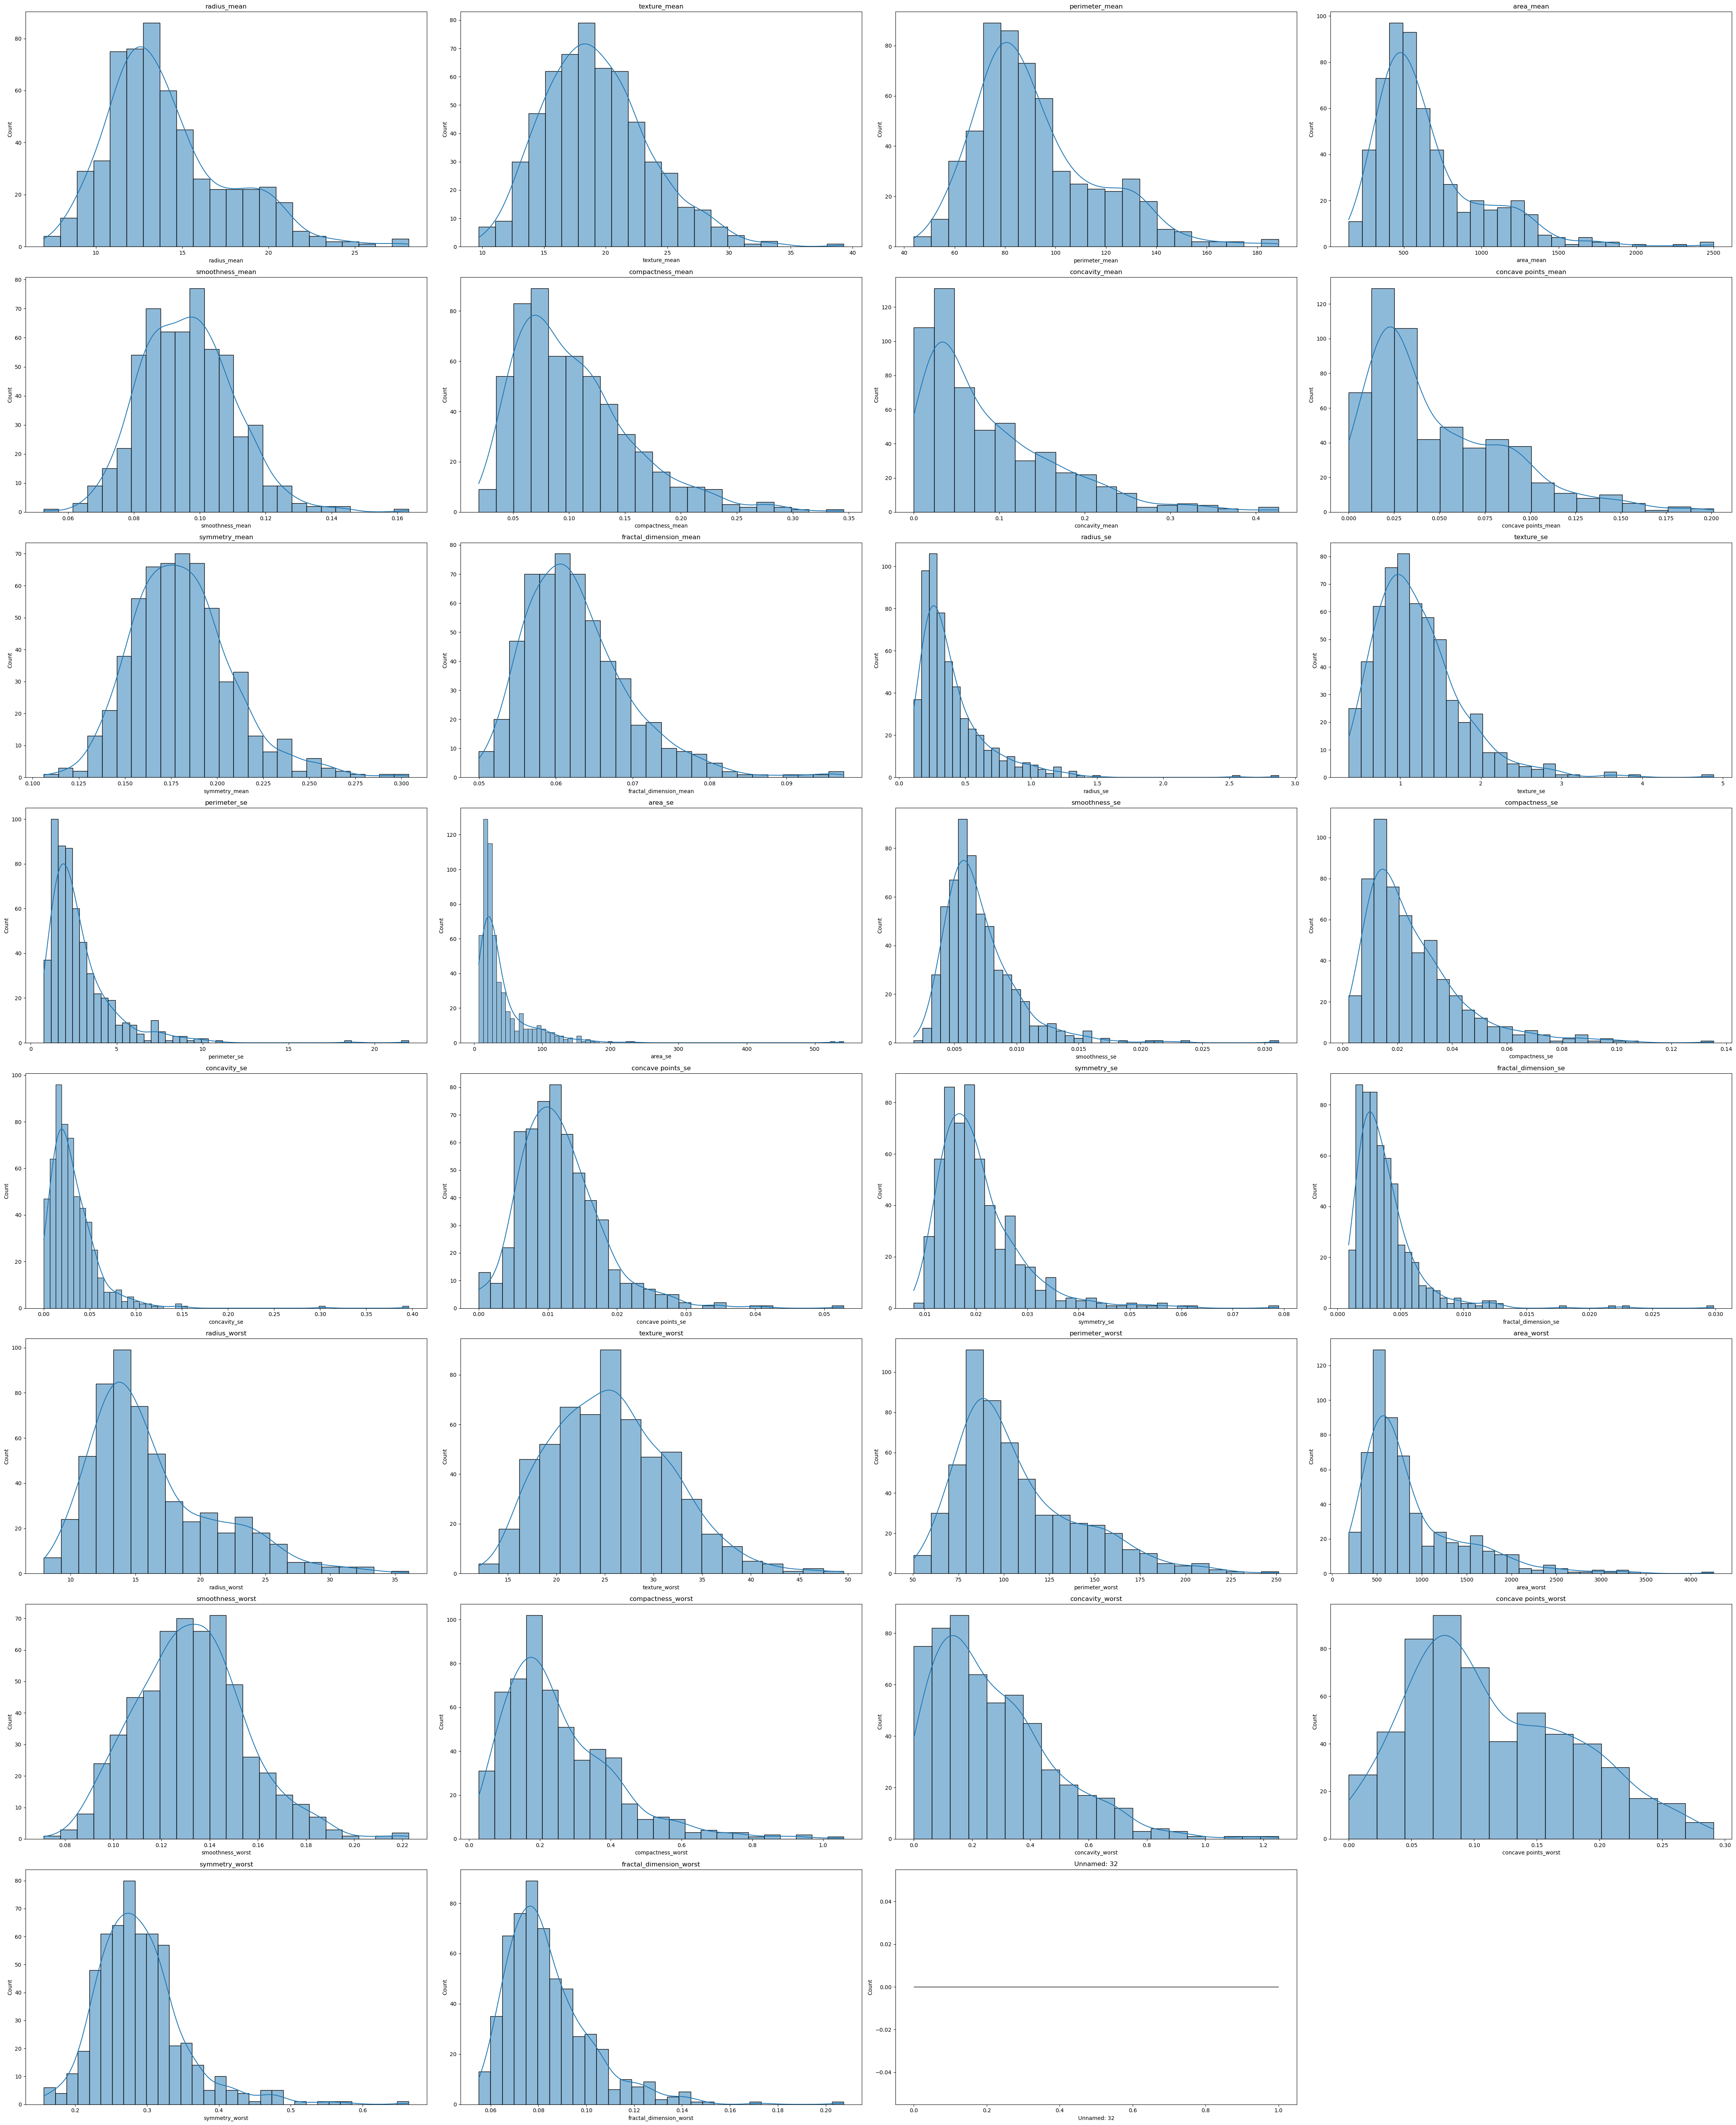

In [13]:
# Import Seaborn library
# Used for creating beautiful statistical visualizations
import seaborn as sns

# Import pyplot module from Matplotlib
# Used for plotting graphs and controlling figures
import matplotlib.pyplot as plt


# Create a new dataframe by dropping unnecessary columns
# 'id' → usually just a unique identifier (not useful for learning)
# 'diagnosis' → target/output column (not included for feature visualization)
# axis=1 means drop columns
df = data.drop(['id', 'diagnosis'], axis=1)


# Create a figure (canvas) where all plots will be drawn
# figsize=(width, height)
# Large size because many graphs will be displayed
plt.figure(figsize=(45,55))


# Loop through all columns in dataframe
# enumerate(..., 1) starts numbering from 1
# i → subplot position
# col → current column name
for i, col in enumerate(df.columns, 1):

    # Create subplot grid:
    # 8 rows × 4 columns
    # Place current graph at position i
    plt.subplot(8, 4, i)

    # Draw histogram for current column
    # Histplot shows distribution of values
    # kde=True adds smooth density curve
    sns.histplot(df[col], kde=True)

    # Set title as current column name
    plt.title(col)


# Adjust spacing between plots
# Prevent titles and graphs from overlapping
plt.tight_layout()


# Display all graphs
plt.show()

In [14]:
## creating independent and dependent variables
X = data.iloc[:,2:-1]
y = data.diagnosis

In [15]:
X

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [16]:
y

0      M
1      M
2      M
3      M
4      M
      ..
564    M
565    M
566    M
567    M
568    B
Name: diagnosis, Length: 569, dtype: object

In [17]:
data.head(1)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,NaN


In [18]:
# Import train_test_split function from sklearn
# Used to divide dataset into training and testing sets
from sklearn.model_selection import train_test_split


# Split the data into training and testing datasets
# X → Input features (independent variables)
# y → Target variable (output/label)

# test_size=0.2
# → 20% of data goes to testing
# → 80% of data goes to training

# random_state=10
# → Fixes randomness so you get the same split every time
# → Useful for reproducibility

X_train, X_test, y_train, y_test = train_test_split(
    X,          # Features dataset
    y,          # Target dataset
    test_size=0.2,
    random_state=10
)

In [19]:
# Import StandardScaler
# Used to scale/standardize data so all features are on a similar scale
from sklearn.preprocessing import StandardScaler


# Create an object of StandardScaler
# This object will calculate mean and standard deviation
sc = StandardScaler()


# Fit and transform training data
# fit() → Learns Mean and Standard Deviation from X_train
# transform() → Applies scaling formula

# Formula:
# Scaled Value = (X - Mean) / Standard Deviation

X_train_scaled = sc.fit_transform(X_train)


# Transform testing data using SAME mean and std
# IMPORTANT:
# We DO NOT use fit_transform() on test data
# Otherwise model accidentally learns from test data (Data Leakage)

X_test_scaled = sc.transform(X_test)

In [20]:
X_train_scaled

array([[ 1.77441228,  2.35932161,  1.91226601, ...,  2.25330862,
         2.03215   ,  2.2008957 ],
       [-0.1322665 , -1.38923972, -0.19179709, ..., -0.8955658 ,
        -0.13570987, -0.90420962],
       [ 0.31439324,  0.82581925,  0.29904315, ...,  0.46725269,
        -0.59363596, -0.88537737],
       ...,
       [-0.53146865, -1.62264951, -0.56053374, ..., -0.15041231,
         0.35651781, -0.46220569],
       [-0.10993352, -0.46960512, -0.17643306, ..., -1.0017555 ,
        -0.92293113, -0.68930044],
       [ 1.81070339,  2.77712515,  1.73436674, ...,  0.74565834,
        -0.05853131, -0.11547077]])

In [21]:
X_test_scaled

array([[ 0.33951785, -1.71134524,  0.39203595, ...,  1.00124386,
         0.53831618,  0.92694953],
       [-1.37090981,  0.63442322, -1.36633653, ..., -1.38817646,
        -0.80116052, -0.57242973],
       [-0.15459949, -0.73569229, -0.20069205, ..., -0.71528673,
         0.72182964, -0.40183172],
       ...,
       [-0.68221631, -0.45793463, -0.70932221, ..., -0.96341767,
        -0.21117334, -0.16919807],
       [ 1.70183007,  0.534057  ,  1.74245307, ...,  2.30655561,
         4.55503123,  1.00449408],
       [ 0.85038493,  0.67877108,  0.87317259, ...,  0.54636249,
         0.28276941, -0.52202577]])

In [22]:
## check train and test data

In [23]:
# Import MLPClassifier
# MLP = Multi Layer Perceptron (Artificial Neural Network)
# Used for classification problems

from sklearn.neural_network import MLPClassifier


# Create the Neural Network model

model = MLPClassifier(hidden_layer_sizes=(50,3),
                      learning_rate_init=0.1,
                      max_iter=100,
                      random_state=2)

    
    # Hidden Layers:
    # First hidden layer → 50 neurons
    # Second hidden layer → 3 neurons
    # Architecture:
    # Input → 50 → 3 → Output

    
    # Controls how much weights update during training
    # Higher → learns faster but may overshoot
    # Lower → learns slower but stable

    
    # Maximum number of training iterations (epochs)
    # Training stops after 100 iterations
    # unless convergence happens earlier

    
    # Makes results reproducible



# Train the model
# Model learns patterns from training data

model.fit(
    X_train_scaled,
    y_train
)


# Predict probability for each class
# Returns probability values

y_predict_proba = model.predict_proba(X_test_scaled)

# Example output:
# [[0.98 0.02]
#  [0.10 0.90]]
#
# Meaning:
# Row 1 → 98% Class 0 , 2% Class 1
# Row 2 → 10% Class 0 , 90% Class 1


# Predict final class labels
# Converts probabilities into actual output classes

y_predict = model.predict(X_test_scaled)

In [24]:
y_predict

array(['M', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'M', 'M', 'B', 'B', 'M',
       'B', 'B', 'M', 'B', 'B', 'B', 'B', 'M', 'M', 'B', 'B', 'M', 'M',
       'B', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B',
       'B', 'B', 'B', 'B', 'M', 'B', 'M', 'M', 'M', 'M', 'B', 'B', 'B',
       'M', 'B', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'B', 'M', 'B', 'B',
       'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'B',
       'M', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B',
       'B', 'M', 'B', 'B', 'B', 'M', 'B', 'M', 'B', 'M', 'B', 'B', 'B',
       'B', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'M', 'M'], dtype='<U1')

In [25]:
## Evaluating the model created
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score, recall_score, f1_score
print("Test accuracy :",accuracy_score(y_test,y_predict))

Test accuracy : 0.956140350877193


In [26]:
## getting the confusion matrix
pd.crosstab(y_test,y_predict)

col_0,B,M
diagnosis,,
B,74,1
M,4,35


In [27]:
print("Precision:", precision_score(y_test, y_predict, average='macro'))
print("Recall:", recall_score(y_test, y_predict, average='macro'))
print("F1 Score:", f1_score(y_test, y_predict, average='macro'))

Precision: 0.9604700854700854
Recall: 0.9420512820512821
F1 Score: 0.9503267973856209
